In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import Normalize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import math

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

from utils_dir.backbones_utils import load_clip_to_cpu, load_backbone_and_tokenizer

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Embedding Analysis
Show, for vanilla CLIP vs RS CLIP:
* text embeddings for zero-shot prompt "a satellite image of a [class]"
* text embedding for the learned CoOp prompt vector (with class name)
* visual embeddings for 10-shot prototype image crops

In [2]:
dataset='mar'
N=10
M_list=[1,2,3]

#### Get text embeddings

In [3]:
# Get class names
clip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_clip-14.pt")
label_names = clip_zs['label_names']
print(label_names)

['B-1B', 'B-52', 'C-130', 'C-17', 'C-5', 'E-3', 'E-8', 'F-15', 'F-16', 'F-22', 'FA-18', 'KC-1', 'KC-135', 'P-3C', 'SU-24', 'SU-34', 'SU-35', 'TU-160', 'TU-22', 'TU-95']


In [4]:
# Load zeroshot prototypes

# clip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_clip-14.pt")
# georsclip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_georsclip-14.pt")
# remoteclip_zs = torch.load(f"run/text_prototypes/boxes/{dataset}/prototypes_remoteclip-14.pt")

# label_names = clip_zs['label_names']
# clip_zs = clip_zs['prototypes']
# georsclip_zs = georsclip_zs['prototypes']
# remoteclip_zs = remoteclip_zs['prototypes']

# Load zeroshot prototypes
device = 'cuda' if torch.cuda.is_available() else 'cpu'

templates = ['an image of a {}', 'a satellite image of a {}', 'an aerial photo of a {}']
#templates = ['a satellite image of a {}']
backbone_types = ['clip-14', 'georsclip-14', 'remoteclip-14']  # edit as needed

def get_features(backbone_type, prompts, device):
    model, tokenizer = load_backbone_and_tokenizer(backbone_type)
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        if any(b in backbone_type for b in ('openclip', 'remoteclip', 'georsclip')):
            tokens = tokenizer(prompts).to(device)
            features = model.encode_text(tokens)
        else:
            tokens = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True).to(device)
            features = model.get_text_features(**tokens)
    return F.normalize(features, p=2, dim=-1)

# Each list contains 3 tensors, one per template, each of shape (num_classes, dim)
clip_zs_list, georsclip_zs_list, remoteclip_zs_list = [], [], []
results = {'clip-14': clip_zs_list, 'georsclip-14': georsclip_zs_list, 'remoteclip-14': remoteclip_zs_list}

for backbone_type in backbone_types:
    for template in templates:
        prompts = [template.format(c) for c in label_names]
        features = get_features(backbone_type, prompts, device)  # (num_classes, dim)
        results[backbone_type].append(features)

LOADED CLIP_14!
LOADED CLIP_14!
LOADED CLIP_14!


LOADED GEORSCLIP_14!


/home/gridsan/manderson/.local/lib/python3.9/site-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


LOADED GEORSCLIP_14!


LOADED GEORSCLIP_14!


LOADED REMOTECLIP_14!


LOADED REMOTECLIP_14!


LOADED REMOTECLIP_14!


In [5]:
NEW_CNAMES = {
    "airplane": "airplane",
    "airport": "airport",
    "background": "background",
    "baseballfield": "baseball field",
    "basketballcourt": "basketball court",
    "bridge": "bridge",
    "chimney": "chimney",
    "dam": "dam",
    "Expressway-Service-area": "expressway service area",
    "Expressway-toll-station": "expressway toll station",
    "golffield": "golf field",
    "groundtrackfield": "ground track field",
    "harbor": "harbor",
    "overpass": "overpass",
    "ship": "ship",
    "stadium": "stadium",
    "storagetank": "storage tank",
    "tenniscourt": "tennis court",
    "trainstation": "train station",
    "vehicle": "vehicle",
    "windmill": "windmill",
    "car": "car",
    "truck": "truck",
    "airliner": "airliner",
    "stairtruck": "stair truck",
    "van": "van",
    "bus": "bus",
    "longvehicle": "long vehicle",
    "boat": "boat",
    "propeller": "propeller aircraft",
    "chartered": "chartered aircraft",
    "pushbacktruck": "pushback truck",
    "other": "others",
    "fighter": "fighter aircraft",
    "trainer": "trainer aircraft",
    "helicopter": "helicopter",
    "SU-35":  "SU-35 aircraft",
    "C-130":  "C-130 aircraft",
    "C-17":   "C-17 aircraft",
    "C-5":    "C-5 aircraft",
    "F-16":   "F-16 aircraft",
    "TU-160": "TU-160 aircraft",
    "E-3":    "E-3 aircraft",
    "B-52":   "B-52 aircraft",
    "P-3C":   "P-3C aircraft",
    "B-1B":   "B-1B aircraft",
    "E-8":    "E-8 aircraft",
    "TU-22":  "TU-22 aircraft",
    "F-15":   "F-15 aircraft",
    "KC-135": "KC-135 aircraft",
    "F-22":   "F-22 aircraft",
    "FA-18":  "FA-18 aircraft",
    "TU-95":  "TU-95 aircraft",
    "KC-1":   "KC-1 aircraft",
    "SU-34":  "SU-34 aircraft",
    "SU-24":  "SU-24 aircraft",
}

In [6]:
# # Load CoOp prototypes

nctx=4
ctp='end'

# if dataset == 'mar':
#     clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_2/prototypes_clip-14.pt")
#     georsclip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_2/prototypes_georsclip-14.pt")
#     remoteclip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_2/prototypes_remoteclip-14.pt")

if dataset == 'nwpu':
    clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M_list[0]}/{dataset}_clip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")
else:
    clip_coop = torch.load(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M_list[0]}/{dataset}_clip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")
coop_label_names = [NEW_CNAMES.get(n, n) for n in clip_coop['label_names']]
zs_label_names   = [NEW_CNAMES.get(n, n) for n in label_names]
print("CoOp order:", coop_label_names)
print("ZS order:  ", zs_label_names)

missing = [n for n in zs_label_names if n not in coop_label_names]
if missing:
    print("WARNING - missing from CoOp:", missing)

reorder_idx = [coop_label_names.index(n) for n in zs_label_names]

def load_coop(path):
    data = torch.load(path)
    proto = F.normalize(data['prototypes'].float(), dim=-1)
    return proto[reorder_idx]

if dataset == 'nwpu':
    clip_coop_list      = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")       
                           for M in M_list]
    georsclip_coop_list  = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_georsclip-14.pt") 
                            for M in M_list]
    remoteclip_coop_list = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_1/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_remoteclip-14.pt") 
                            for M in M_list]
else:
    clip_coop_list       = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_clip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_clip-14.pt")       
                            for M in M_list]
    georsclip_coop_list  = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_georsclip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_georsclip-14.pt")  
                            for M in M_list]
    remoteclip_coop_list = [load_coop(f"run/coop_prototypes/boxes/{dataset}_N{N}-{M}/{dataset}_remoteclip_2/nctx{nctx}_cscFalse_ctp{ctp}/prototypes_remoteclip-14.pt") 
                            for M in M_list]

CoOp order: ['B-1B aircraft', 'B-52 aircraft', 'C-130 aircraft', 'C-17 aircraft', 'C-5 aircraft', 'E-3 aircraft', 'E-8 aircraft', 'F-15 aircraft', 'F-16 aircraft', 'F-22 aircraft', 'FA-18 aircraft', 'KC-1 aircraft', 'KC-135 aircraft', 'P-3C aircraft', 'SU-24 aircraft', 'SU-34 aircraft', 'SU-35 aircraft', 'TU-160 aircraft', 'TU-22 aircraft', 'TU-95 aircraft']
ZS order:   ['B-1B aircraft', 'B-52 aircraft', 'C-130 aircraft', 'C-17 aircraft', 'C-5 aircraft', 'E-3 aircraft', 'E-8 aircraft', 'F-15 aircraft', 'F-16 aircraft', 'F-22 aircraft', 'FA-18 aircraft', 'KC-1 aircraft', 'KC-135 aircraft', 'P-3C aircraft', 'SU-24 aircraft', 'SU-34 aircraft', 'SU-35 aircraft', 'TU-160 aircraft', 'TU-22 aircraft', 'TU-95 aircraft']


In [7]:
print(len(label_names))
print('Label names:', label_names)
print('Shape of prototypes:')
print(len(clip_zs_list))
print(clip_zs_list[0].shape)
print(georsclip_zs_list[0].shape)
print(remoteclip_zs_list[0].shape)
print(len(clip_coop_list))
print(clip_coop_list[0].shape)
print(georsclip_coop_list[0].shape)
print(remoteclip_coop_list[0].shape)

20
Label names: ['B-1B', 'B-52', 'C-130', 'C-17', 'C-5', 'E-3', 'E-8', 'F-15', 'F-16', 'F-22', 'FA-18', 'KC-1', 'KC-135', 'P-3C', 'SU-24', 'SU-34', 'SU-35', 'TU-160', 'TU-22', 'TU-95']
Shape of prototypes:
3
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])
3
torch.Size([20, 768])
torch.Size([20, 768])
torch.Size([20, 768])


#### Get prototype crop embeddings

In [8]:
# Load CLIP models
clip_model = load_clip_to_cpu('clip-14')
georsclip_model = load_clip_to_cpu('georsclip-14')
remoteclip_model = load_clip_to_cpu('remoteclip-14')

in backbone utils
-> using backbone: clip-14
LOADED CLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: georsclip-14
LOADED GEORSCLIP-14! (load_clip_to_cpu)
in backbone utils
-> using backbone: remoteclip-14
LOADED REMOTECLIP-14! (load_clip_to_cpu)


In [9]:
PIXEL_MEAN = [0.48145466, 0.4578275, 0.40821073]
PIXEL_STD = [0.26862954, 0.26130258, 0.27577711]
coop_normalize = Normalize(mean=PIXEL_MEAN, std=PIXEL_STD)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    coop_normalize
])

def extract_embeddings(crop_path, label_names, model, transform, device="cuda"):
    crop_path = Path(crop_path)
    all_embeds = []

    with torch.no_grad():
        for label in label_names:
            img_paths = sorted((crop_path / label).glob("*.jpg"))

            images = torch.stack([
                transform(Image.open(p).convert("RGB"))
                for p in img_paths
            ]).to(device)

            feats = model.to(device).visual(images.type(model.dtype))
            feats = torch.nn.functional.normalize(feats, dim=-1)

            all_embeds.append(feats)

    return torch.stack(all_embeds)  # [num_classes, N, D]

In [10]:
clip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, clip_model, transform)
    for M in M_list
]
print(len(clip_crop_embed_list))
print(clip_crop_embed_list[0].shape)

georsclip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, georsclip_model, transform)
    for M in M_list
]
print(len(georsclip_crop_embed_list))
print(georsclip_crop_embed_list[0].shape)

remoteclip_crop_embed_list = [
    extract_embeddings(f"data/cropped_data/{dataset}/train/{dataset}_N{N}-{M}", label_names, remoteclip_model, transform)
    for M in M_list
]
print(len(remoteclip_crop_embed_list))
print(remoteclip_crop_embed_list[0].shape)

3
torch.Size([20, 10, 768])
3
torch.Size([20, 10, 768])
3
torch.Size([20, 10, 768])


In [11]:
plot_umap_simple(
    clip_zs_list[1],
    clip_coop_list,
    clip_crop_embed_list,
    "CLIP",
    label_names
)

NameError: name 'plot_umap_simple' is not defined

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


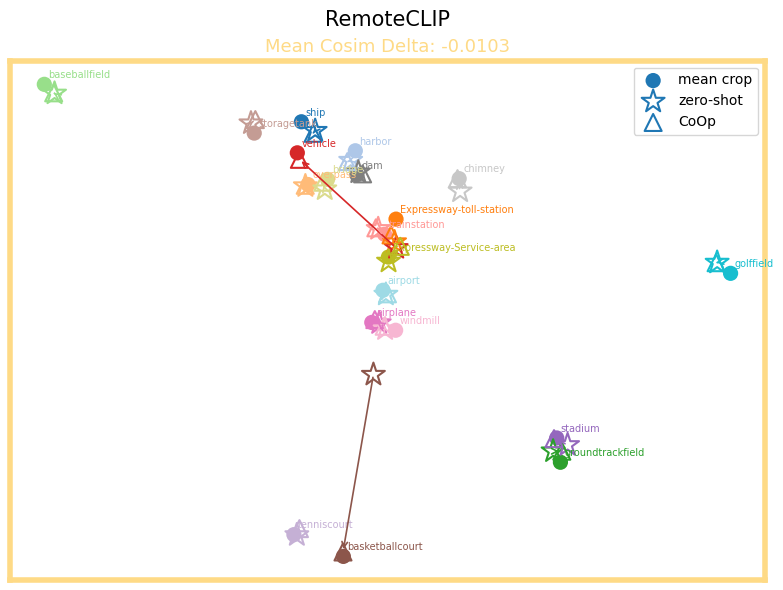

In [159]:
plot_umap_simple(
    remoteclip_zs_list[1],
    remoteclip_coop_list,
    remoteclip_crop_embed_list,
    "RemoteCLIP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


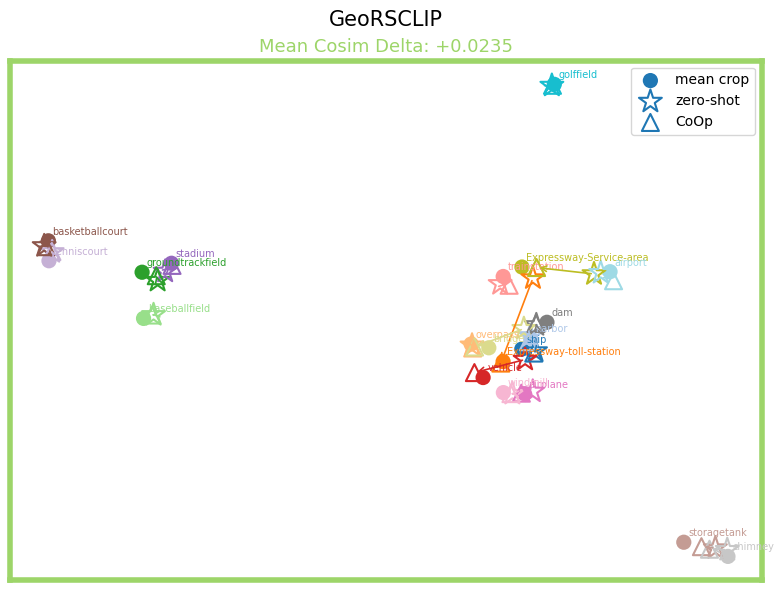

In [160]:
plot_umap_simple(
    georsclip_zs_list[1],
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP",
    label_names
)

In [11]:
def contrast_score(text_protos, crop_embed):
    C, S, D = crop_embed.shape
    scores = []
    for i in range(C):
        sim_correct   = (text_protos[i] * crop_embed[i]).sum(-1).mean()
        other_crops   = torch.cat([crop_embed[:i], crop_embed[i+1:]], dim=0).reshape(-1, D)
        sim_incorrect = (text_protos[i] * other_crops).sum(-1).mean()
        scores.append((sim_correct - sim_incorrect).item())
    return np.array(scores)

for name, zs, coop_list, crops in [
    ('CLIP',       clip_zs_list[1],       clip_coop_list,       clip_crop_embed_list),
    ('GeoRSCLIP',  georsclip_zs_list[1],  georsclip_coop_list,  georsclip_crop_embed_list),
    ('RemoteCLIP', remoteclip_zs_list[1], remoteclip_coop_list, remoteclip_crop_embed_list),
]:
    zs_cpu   = zs.cpu()
    coop_cpu = F.normalize(torch.stack(coop_list).mean(0), dim=-1).cpu()
    crops_cpu = crops.cpu()

    zs_scores   = contrast_score(zs_cpu,   crops_cpu)
    coop_scores = contrast_score(coop_cpu, crops_cpu)
    delta       = coop_scores - zs_scores

    print(f"\n=== {name} ===")
    print(f"  ZS   mean contrast: {zs_scores.mean():.4f}")
    print(f"  CoOp mean contrast: {coop_scores.mean():.4f}")
    print(f"  Mean delta:         {delta.mean():+.4f}")
    for i, (lab, d) in enumerate(zip(label_names, delta)):
        print(f"    {lab:30s}: {d:+.4f}")

AttributeError: 'list' object has no attribute 'cpu'

#### UMAP

In [37]:
def plot_umap(text_zs_list, text_coop_list, crop_embed_list, title, class_names=None, zs_labels=None):
    text_coop_list   = [t.detach().cpu().float() for t in text_coop_list]
    text_zs_list     = [t.detach().cpu().float() for t in text_zs_list]
    crop_embed_list  = [t.detach().cpu().float() for t in crop_embed_list]
    if zs_labels is None:
        zs_labels = [f"zero-shot {i}" for i in range(len(text_zs_list))]
    C, S, D = crop_embed_list[0].shape
    N = len(text_zs_list)

    # use mean crops for UMAP layout
    crop_embed_mean = torch.stack(crop_embed_list).mean(0)
    text_coop_mean  = torch.stack(text_coop_list).mean(0)
    X = torch.cat([*text_zs_list, text_coop_mean, crop_embed_mean.reshape(-1, D)], dim=0).numpy()
    Z = umap.UMAP(n_components=2, metric="cosine", random_state=0).fit_transform(X)

    colors     = np.arange(C)
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(colors))
    labels     = class_names if class_names else [str(i) for i in range(C)]

    # per-seed crop mean, delta per seed then average
    sim_zs_ref = (F.normalize(text_zs_list[1] if len(text_zs_list) > 1 else text_zs_list[0], dim=-1) *
                  F.normalize(F.normalize(crop_embed_list[0], dim=-1).mean(dim=1), dim=-1)).sum(-1)  # shape (C,)
    deltas = []
    for coop, crops in zip(text_coop_list, crop_embed_list):
        crop_mean_m = F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)
        sim_zs_m    = (F.normalize(text_zs_list[1] if len(text_zs_list) > 1 else text_zs_list[0], dim=-1) * crop_mean_m).sum(-1)
        sim_coop_m  = (F.normalize(coop, dim=-1) * crop_mean_m).sum(-1)
        deltas.append(sim_coop_m - sim_zs_m)
    delta    = torch.stack(deltas).mean(0).numpy()
    sim_coop = torch.stack([( F.normalize(coop, dim=-1) * F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)).sum(-1)
                             for coop, crops in zip(text_coop_list, crop_embed_list)]).mean(0).numpy()
    zs_sims  = [(F.normalize(t, dim=-1) * F.normalize(F.normalize(crop_embed_mean, dim=-1).mean(dim=1), dim=-1)).sum(-1).numpy()
                for t in text_zs_list]

    # --- plot 1: UMAP ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(Z[N*C:, 0], Z[N*C:, 1], c=np.repeat(colors, Z[N*C:].shape[0] // C), cmap="tab20", vmin=0, vmax=C-1,
               marker=".", s=60, alpha=0.5, linewidths=0, label="image crops")
    for i, label in enumerate(zs_labels):
        ax.scatter(Z[i*C:(i+1)*C, 0], Z[i*C:(i+1)*C, 1],
                   facecolors="none", edgecolors=cls_colors, marker="*", s=40, linewidths=1.2,
                   label="zero-shot" if i == 0 else "_nolegend_")
    ax.scatter(Z[N*C:(N+1)*C, 0], Z[N*C:(N+1)*C, 1],
               facecolors="none", edgecolors=cls_colors, marker="^", s=40, linewidths=1.2, label="CoOp text")
    ax.set_title(title); ax.legend(); plt.tight_layout(); plt.show()

    # --- plot 2: per-class alignment ---
    x = np.arange(C)
    width = 0.8 / (N + 1)
    fig, ax = plt.subplots(figsize=(max(8, C*0.5), 4))
    for i, (sim, label) in enumerate(zip(zs_sims, zs_labels)):
        ax.bar(x + (i - N/2) * width, sim, width, label=label, alpha=0.8)
    ax.bar(x + (N - N/2) * width, sim_coop, width, label="CoOp", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("cosine sim to mean crop"); ax.legend()
    ax.set_title("Per-class text-image alignment"); plt.tight_layout(); plt.show()

    # --- plot 3: delta ---
    fig, ax = plt.subplots(figsize=(max(8, C*0.5), 4))
    ax.bar(x, delta, color=["green" if d > 0 else "red" for d in delta], alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("CoOp − zero-shot"); ax.set_title("Alignment delta (CoOp vs zero-shot)")
    plt.tight_layout(); plt.show()

In [38]:
def plot_umap_perclass(text_zs_list, text_coop_list, crop_embed_list, title, class_names=None):
    text_coop_list  = [t.detach().cpu().float() for t in text_coop_list]
    text_zs_list    = [t.detach().cpu().float() for t in text_zs_list]
    crop_embed_list = [t.detach().cpu().float() for t in crop_embed_list]
    C, S, D = crop_embed_list[0].shape
    N = len(text_zs_list)

    # use mean crops for UMAP layout
    crop_embed_mean = torch.stack(crop_embed_list).mean(0)
    crops_flat  = F.normalize(crop_embed_mean.reshape(-1, D), dim=-1).numpy()
    zs_n_list   = [F.normalize(t, dim=-1).numpy() for t in text_zs_list]
    coop_n      = F.normalize(torch.stack(text_coop_list).mean(0), dim=-1).numpy()

    reducer   = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    Z_crops   = reducer.fit_transform(crops_flat)
    Z_zs_list = [reducer.transform(zs_n) for zs_n in zs_n_list]
    Z_coop    = reducer.transform(coop_n)

    # delta: per seed, matched crop mean, then average
    deltas = []
    for coop, crops in zip(text_coop_list, crop_embed_list):
        crop_mean_m = F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)
        sim_zs_m    = (F.normalize(text_zs_list[1] if len(text_zs_list) > 1 else text_zs_list[0], dim=-1) * crop_mean_m).sum(-1)
        sim_coop_m  = (F.normalize(coop, dim=-1) * crop_mean_m).sum(-1)
        deltas.append(sim_coop_m - sim_zs_m)
    delta    = torch.stack(deltas).mean(0).numpy()

    crop_mean_viz = F.normalize(F.normalize(crop_embed_mean, dim=-1).mean(dim=1), dim=-1)
    crop_mean_n   = crop_mean_viz.numpy()
    Z_crop_mean   = reducer.transform(crop_mean_n)

    labels     = class_names if class_names else [str(i) for i in range(C)]
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C - 1)
    cls_colors = cmap(norm(np.arange(C)))

    abs_max    = np.abs(delta).max()
    delta_norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    delta_cmap = plt.get_cmap("RdYlGn")

    ncols = min(5, C)
    nrows = math.ceil(C / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(C):
        ax = axes[i]
        for spine in ax.spines.values():
            spine.set_edgecolor(delta_cmap(delta_norm(delta[i])))
            spine.set_linewidth(4)

        other_mask = np.ones(C * S, dtype=bool)
        other_mask[i * S:(i + 1) * S] = False
        ax.scatter(Z_crops[other_mask, 0], Z_crops[other_mask, 1], c="lightgrey", s=20, alpha=0.3, linewidths=0)
        ax.scatter(Z_crops[i*S:(i+1)*S, 0], Z_crops[i*S:(i+1)*S, 1], c=[cls_colors[i]], s=100, alpha=0.9, linewidths=0)
        ax.scatter(*Z_crop_mean[i], c="black", s=100, linewidths=0, zorder=5)

        for Z_zs in Z_zs_list:
            ax.scatter(*Z_zs[i], facecolors="none", edgecolors="black", marker="*", s=300, linewidths=1.5)
            ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                        arrowprops=dict(arrowstyle="->", color="black", lw=1.2, alpha=0.5))
        ax.scatter(*Z_coop[i], facecolors="none", edgecolors="black", marker="^", s=200, linewidths=1.5)

        ax.set_title(f"{labels[i]}\n", fontsize=18)
        ax.text(0.5, 1.02, f"{delta[i]:+.3f}", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=15)
                #color=delta_cmap(delta_norm(delta[i])))
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(C, len(axes)):
        axes[j].set_visible(False)

    legend_elements = [
        plt.scatter([], [], c="grey",  s=60, alpha=0.9, linewidths=0, label="image crops"),
        plt.scatter([], [], c="black", s=60, linewidths=0, label="crop mean"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="*", s=150, linewidths=1.5, label="zero-shot"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="^", s=100, linewidths=1.5, label="CoOp"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=17, frameon=True, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(title, fontsize=20, y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.04, top=0.95)
    plt.show()

In [39]:
def plot_umap_single_class(text_zs_list, text_coop_list, crop_embed, title, class_name, class_names):
    text_coop_list = [t.detach().cpu().float() for t in text_coop_list]
    text_zs_list   = [t.detach().cpu().float() for t in text_zs_list]
    crop_embed     = crop_embed.detach().cpu().float()
    C, S, D = crop_embed.shape

    i = class_names.index(class_name)

    crops_flat  = F.normalize(crop_embed.reshape(-1, D), dim=-1).numpy()
    zs_n_list   = [F.normalize(t, dim=-1).numpy() for t in text_zs_list]
    coop_n      = F.normalize(torch.stack(text_coop_list).mean(0), dim=-1).numpy()

    reducer     = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    Z_crops     = reducer.fit_transform(crops_flat)
    Z_zs_list   = [reducer.transform(zs_n) for zs_n in zs_n_list]
    Z_coop      = reducer.transform(coop_n)

    crop_mean   = F.normalize(F.normalize(crop_embed, dim=-1).mean(dim=1), dim=-1)
    sim_zs_ref  = (F.normalize(text_zs_list[1] if len(text_zs_list) > 1 else text_zs_list[0], dim=-1) * crop_mean).sum(-1)
    coops_sims  = [(F.normalize(t, dim=-1) * crop_mean).sum(-1) for t in text_coop_list]
    delta       = torch.stack([s - sim_zs_ref for s in coops_sims]).mean(0).numpy()

    crop_mean_n = F.normalize(crop_mean, dim=-1).numpy()
    Z_crop_mean = reducer.transform(crop_mean_n)

    cmap, norm  = plt.get_cmap("tab20"), plt.Normalize(0, C - 1)
    cls_colors  = cmap(norm(np.arange(C)))
    abs_max     = np.abs(delta).max()
    delta_norm  = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    delta_color = plt.get_cmap("RdYlGn")(delta_norm(delta[i]))

    fig, ax = plt.subplots(figsize=(6, 6))

    other_mask = np.ones(C * S, dtype=bool)
    other_mask[i * S:(i + 1) * S] = False
    ax.scatter(Z_crops[other_mask, 0], Z_crops[other_mask, 1], c="lightgrey", s=20, alpha=0.3, linewidths=0)
    ax.scatter(Z_crops[i*S:(i+1)*S, 0], Z_crops[i*S:(i+1)*S, 1], c=[cls_colors[i]], s=100, alpha=0.9, linewidths=0)
    ax.scatter(*Z_crop_mean[i], c="black", s=100, linewidths=0, zorder=5)

    for Z_zs in Z_zs_list:
        ax.scatter(*Z_zs[i], facecolors="none", edgecolors="black", marker="*", s=300, linewidths=1.5)
        ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.2, alpha=0.5))
    ax.scatter(*Z_coop[i], facecolors="none", edgecolors="black", marker="^", s=200, linewidths=1.5)

    ax.set_title(title, fontsize=15, pad=20)
    ax.text(0.5, 1.0, f"Cosim Delta: {delta[i]:+.3f}", transform=ax.transAxes,
            ha='center', va='bottom', fontsize=12) #color=delta_color)

    legend_elements = [
        plt.scatter([], [], c="grey",  s=60, alpha=0.9, linewidths=0, label="image crops"),
        plt.scatter([], [], c="black", s=60, linewidths=0, label="crop mean"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="*", s=150, linewidths=1.5, label="zero-shot"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="^", s=100, linewidths=1.5, label="CoOp"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

In [40]:
def plot_umap_simple(text_zs, text_coop_list, crop_embed_list, title, class_names=None):
    text_zs         = text_zs.detach().cpu().float()
    text_coop_list  = [t.detach().cpu().float() for t in text_coop_list]
    crop_embed_list = [t.detach().cpu().float() for t in crop_embed_list]
    C, S, D = crop_embed_list[0].shape

    # use mean crops for UMAP layout
    crop_embed_mean = torch.stack(crop_embed_list).mean(0)
    crop_mean_viz   = F.normalize(F.normalize(crop_embed_mean, dim=-1).mean(dim=1), dim=-1)
    crops_flat      = F.normalize(crop_embed_mean.reshape(-1, D), dim=-1).numpy()
    zs_n            = F.normalize(text_zs, dim=-1).numpy()
    coop_n          = F.normalize(torch.stack(text_coop_list).mean(0), dim=-1).numpy()
    crop_mean_n     = crop_mean_viz.numpy()

    reducer     = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    reducer.fit(crops_flat)
    Z_zs        = reducer.transform(zs_n)
    Z_coop      = reducer.transform(coop_n)
    Z_crop_mean = reducer.transform(crop_mean_n)

    # delta: per seed, matched crop mean, then average
    deltas = []
    for coop, crops in zip(text_coop_list, crop_embed_list):
        crop_mean_m = F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)
        sim_zs_m    = (F.normalize(text_zs, dim=-1) * crop_mean_m).sum(-1)
        sim_coop_m  = (F.normalize(coop,    dim=-1) * crop_mean_m).sum(-1)
        deltas.append(sim_coop_m - sim_zs_m)
    delta      = torch.stack(deltas).mean(0).numpy()
    mean_delta = delta.mean()

    colors     = np.arange(C)
    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(colors))
    labels     = class_names if class_names else [str(i) for i in range(C)]

    abs_max      = np.abs(delta).max()
    delta_norm   = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    border_color = plt.get_cmap("RdYlGn")(delta_norm(mean_delta))

    fig, ax = plt.subplots(figsize=(8, 6))
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    ax.scatter(Z_crop_mean[:, 0], Z_crop_mean[:, 1], c=cls_colors, marker="o", s=120, linewidths=0, label="mean crop")
    ax.scatter(Z_zs[:, 0],        Z_zs[:, 1],        facecolors="none", edgecolors=cls_colors, marker="*", s=300, linewidths=1.5, label="zero-shot")
    ax.scatter(Z_coop[:, 0],      Z_coop[:, 1],      facecolors="none", edgecolors=cls_colors, marker="^", s=150, linewidths=1.5, label="CoOp")

    for i in range(C):
        ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                    arrowprops=dict(arrowstyle="->", color=cls_colors[i], lw=1.2))
        ax.annotate(labels[i], Z_crop_mean[i], fontsize=7, ha='left', va='bottom',
                    color=cls_colors[i], xytext=(3, 3), textcoords='offset points')

    ax.set_title(title, fontsize=15, pad=25)
    ax.text(0.5, 1.01, f"Mean Cosim Delta: {mean_delta:+.4f}", ha='center', va='bottom',
            transform=ax.transAxes, fontsize=13, color=border_color)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


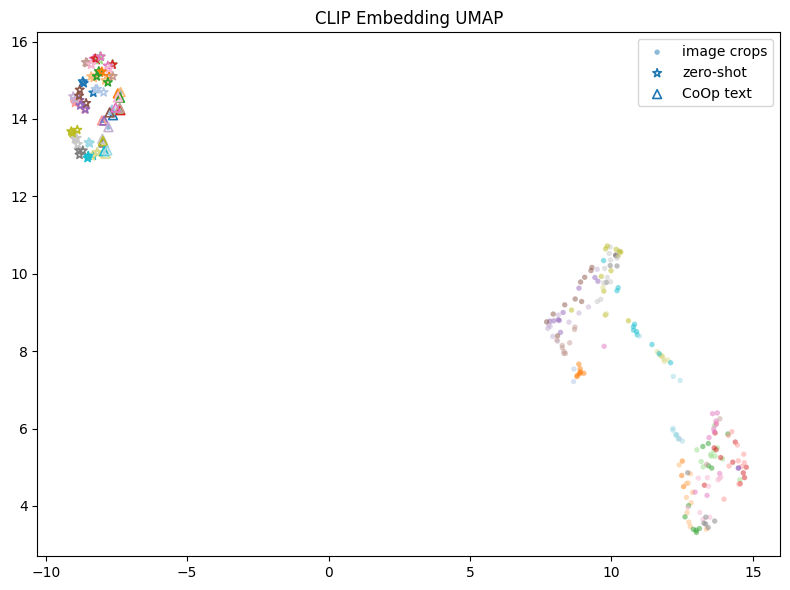

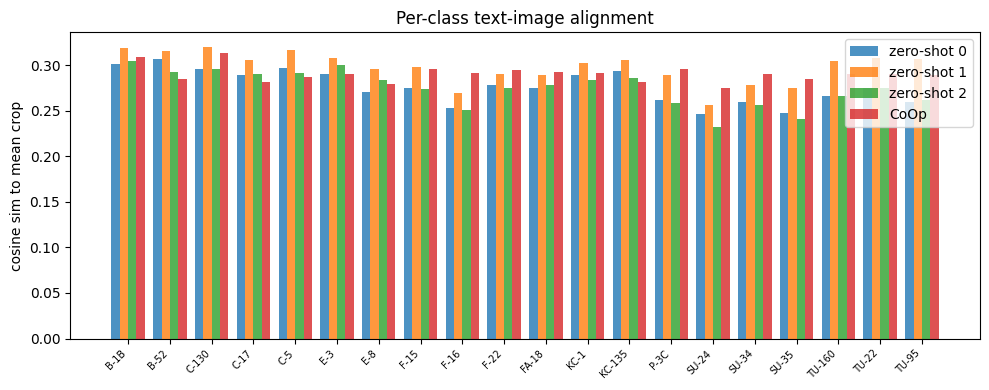

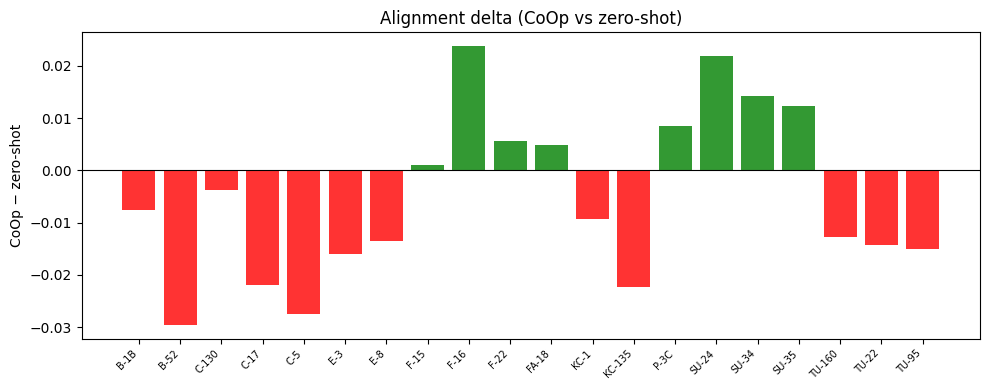

In [15]:
plot_umap(
    clip_zs_list,
    clip_coop_list,
    clip_crop_embed_list,
    "CLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


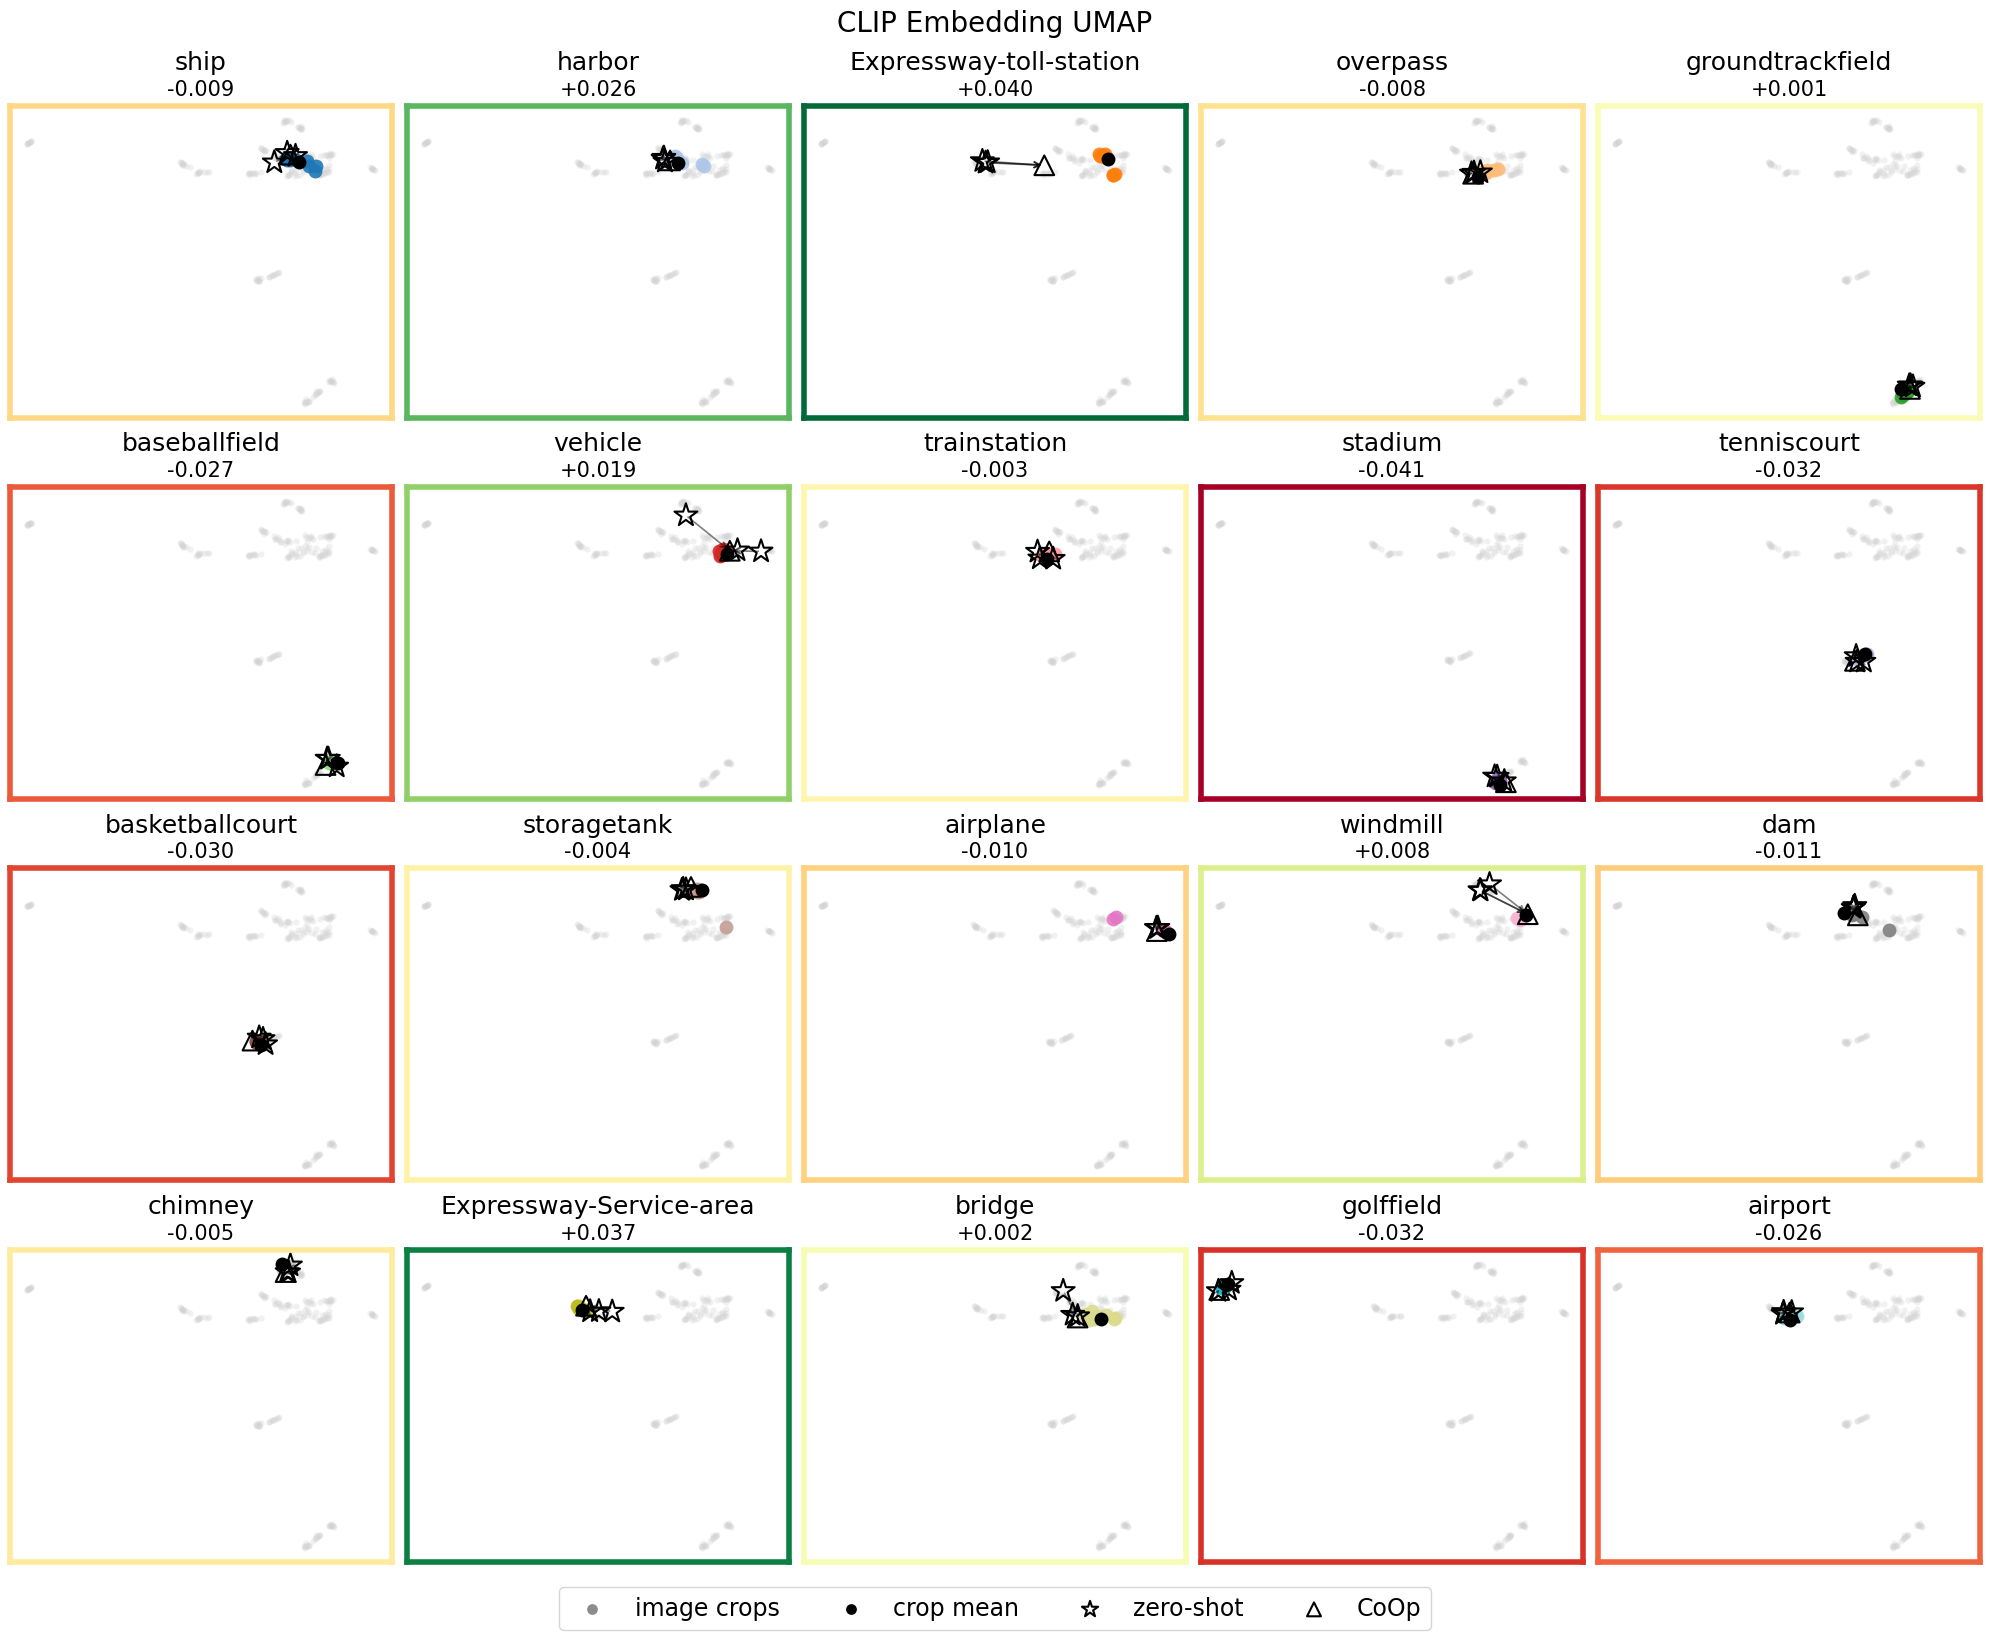

In [66]:
plot_umap_perclass(
    clip_zs_list,
    clip_coop_list,
    clip_crop_embed_list,
    "CLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


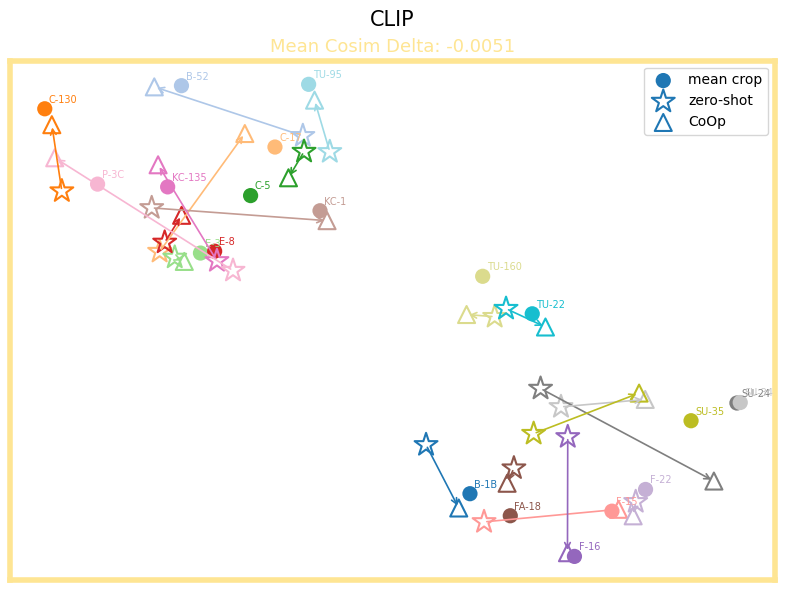

In [111]:
plot_umap_simple(
    clip_zs_list[1],
    clip_coop_list,
    clip_crop_embed_list,
    "CLIP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


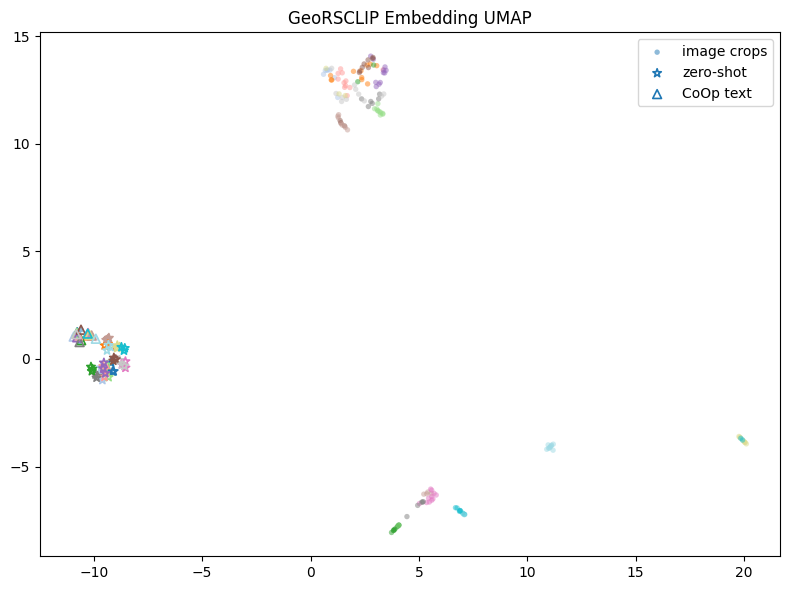

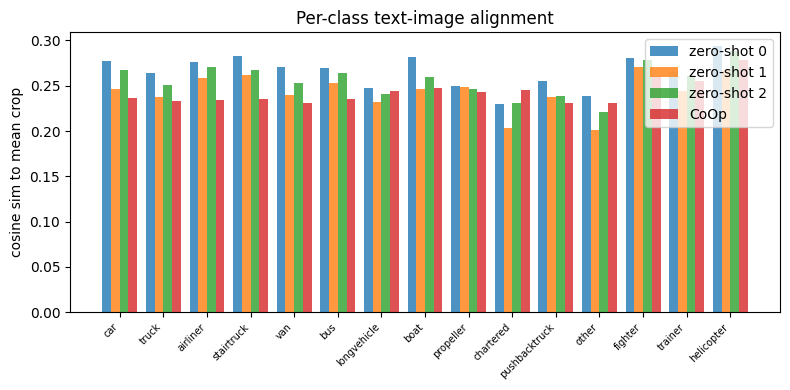

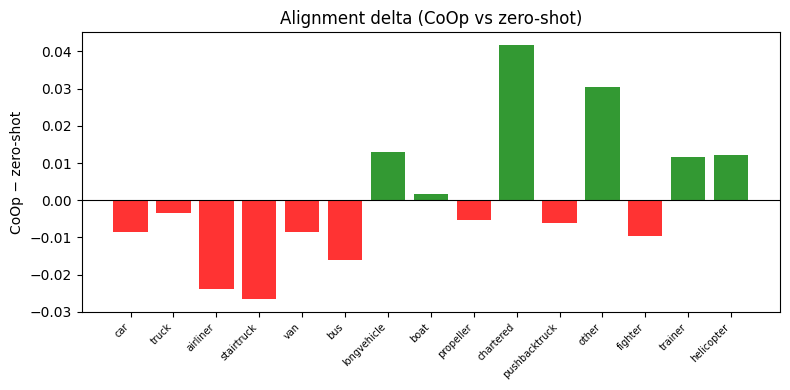

In [41]:
plot_umap(
    georsclip_zs_list,
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP Embedding UMAP",
    label_names
)

In [33]:
def plot_umap_perclass2(text_zs_list, text_coop_list, crop_embed_list, title, class_names=None, display_classes=None, save_name=None):
    text_coop_list  = [t.detach().cpu().float() for t in text_coop_list]
    text_zs_list    = [t.detach().cpu().float() for t in text_zs_list]
    crop_embed_list = [t.detach().cpu().float() for t in crop_embed_list]
    C, S, D = crop_embed_list[0].shape
    N = len(text_zs_list)

    # resolve which class indices to display
    labels = class_names if class_names else [str(i) for i in range(C)]
    if display_classes is not None:
        display_indices = [labels.index(name) for name in display_classes if name in labels]
    else:
        display_indices = list(range(C))

    # use mean crops for UMAP layout
    crop_embed_mean = torch.stack(crop_embed_list).mean(0)
    crops_flat  = F.normalize(crop_embed_mean.reshape(-1, D), dim=-1).numpy()
    zs_n_list   = [F.normalize(t, dim=-1).numpy() for t in text_zs_list]
    coop_n      = F.normalize(torch.stack(text_coop_list).mean(0), dim=-1).numpy()

    reducer   = umap.UMAP(n_components=2, metric="cosine", random_state=0)
    Z_crops   = reducer.fit_transform(crops_flat)
    Z_zs_list = [reducer.transform(zs_n) for zs_n in zs_n_list]
    Z_coop    = reducer.transform(coop_n)

    # delta: per seed, matched crop mean, then average
    deltas = []
    for coop, crops in zip(text_coop_list, crop_embed_list):
        crop_mean_m = F.normalize(F.normalize(crops, dim=-1).mean(dim=1), dim=-1)
        sim_zs_m    = (F.normalize(text_zs_list[1] if len(text_zs_list) > 1 else text_zs_list[0], dim=-1) * crop_mean_m).sum(-1)
        sim_coop_m  = (F.normalize(coop, dim=-1) * crop_mean_m).sum(-1)
        deltas.append(sim_coop_m - sim_zs_m)
    delta    = torch.stack(deltas).mean(0).numpy()

    crop_mean_viz = F.normalize(F.normalize(crop_embed_mean, dim=-1).mean(dim=1), dim=-1)
    crop_mean_n   = crop_mean_viz.numpy()
    Z_crop_mean   = reducer.transform(crop_mean_n)

    n_display = len(display_indices)
    ncols = min(4, n_display)
    nrows = math.ceil(n_display / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for plot_pos, i in enumerate(display_indices):
        ax = axes[plot_pos]
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(4)

        other_mask = np.ones(C * S, dtype=bool)
        other_mask[i * S:(i + 1) * S] = False
        ax.scatter(Z_crops[other_mask, 0], Z_crops[other_mask, 1], c="lightgrey", s=20, alpha=0.3, linewidths=0)
        ax.scatter(Z_crops[i*S:(i+1)*S, 0], Z_crops[i*S:(i+1)*S, 1], c="steelblue", s=100, alpha=0.9, linewidths=0)
        ax.scatter(*Z_crop_mean[i], c="black", s=100, linewidths=0, zorder=5)

        for Z_zs in Z_zs_list:
            ax.scatter(*Z_zs[i], facecolors="none", edgecolors="black", marker="*", s=300, linewidths=1.5)
            ax.annotate("", xy=Z_coop[i], xytext=Z_zs[i],
                        arrowprops=dict(arrowstyle="->", color="black", lw=1.2, alpha=0.5))
        ax.scatter(*Z_coop[i], facecolors="none", edgecolors="black", marker="^", s=200, linewidths=1.5)

        ax.set_title(f"{labels[i]}\n", fontsize=27)
        ax.text(0.5, 1.02, f"{delta[i]:+.3f}", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=24)
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(n_display, len(axes)):
        axes[j].set_visible(False)

    legend_elements = [
        plt.scatter([], [], c="steelblue", s=60, alpha=0.9, linewidths=0, label="image crops"),
        plt.scatter([], [], c="black",     s=80, linewidths=0,             label="image mean"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="*", s=160, linewidths=1.5, label="zero-shot"),
        plt.scatter([], [], facecolors="none", edgecolors="black", marker="^", s=110, linewidths=1.5, label="CoOp"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=27, frameon=True, bbox_to_anchor=(0.5, -0.01), markerscale=2)
    #fig.suptitle(title, fontsize=20, y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.04, top=0.9, hspace=0.4)

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


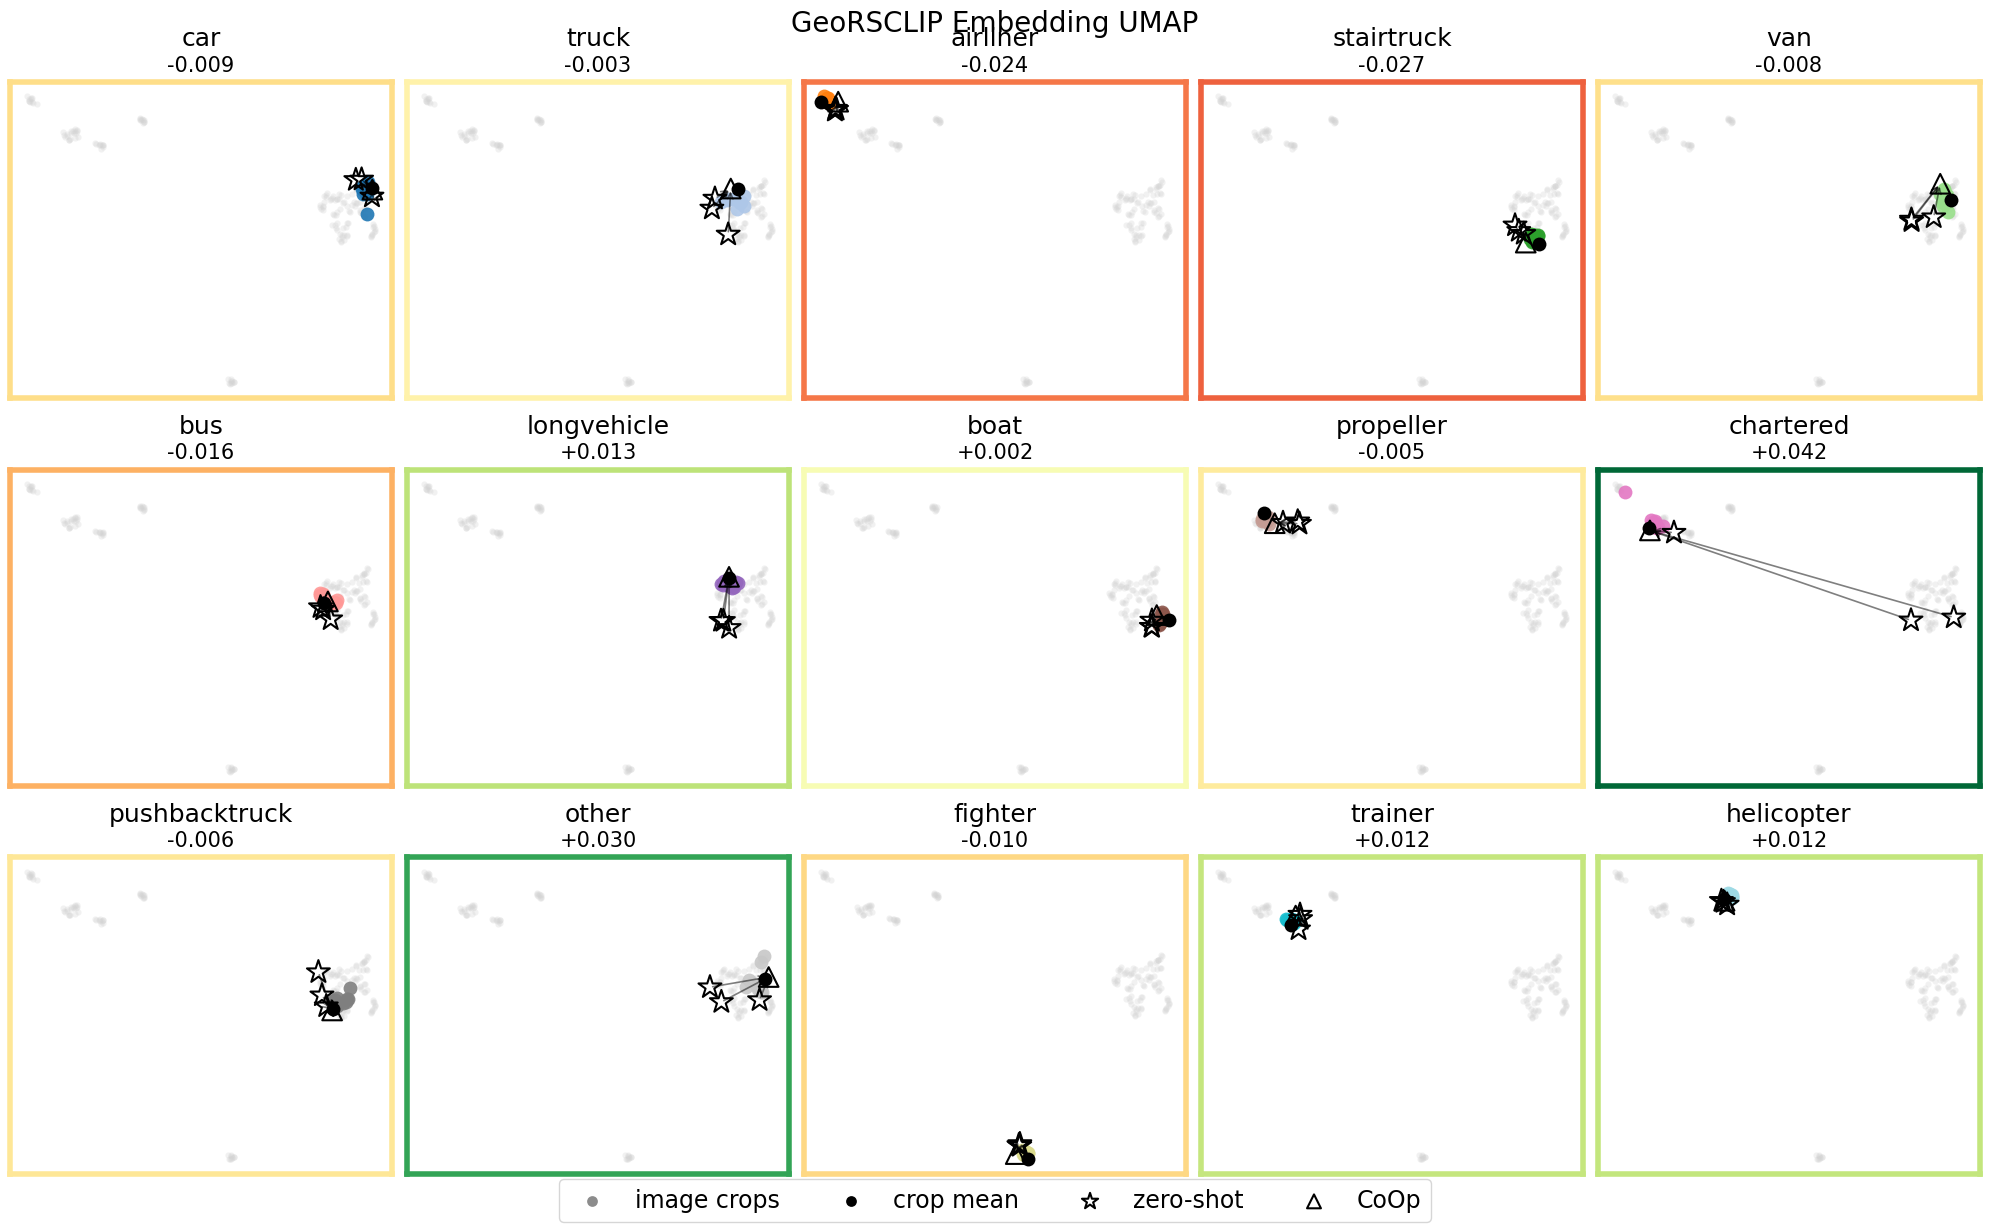

In [43]:
plot_umap_perclass(
    georsclip_zs_list,
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP Embedding UMAP",
    label_names,
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


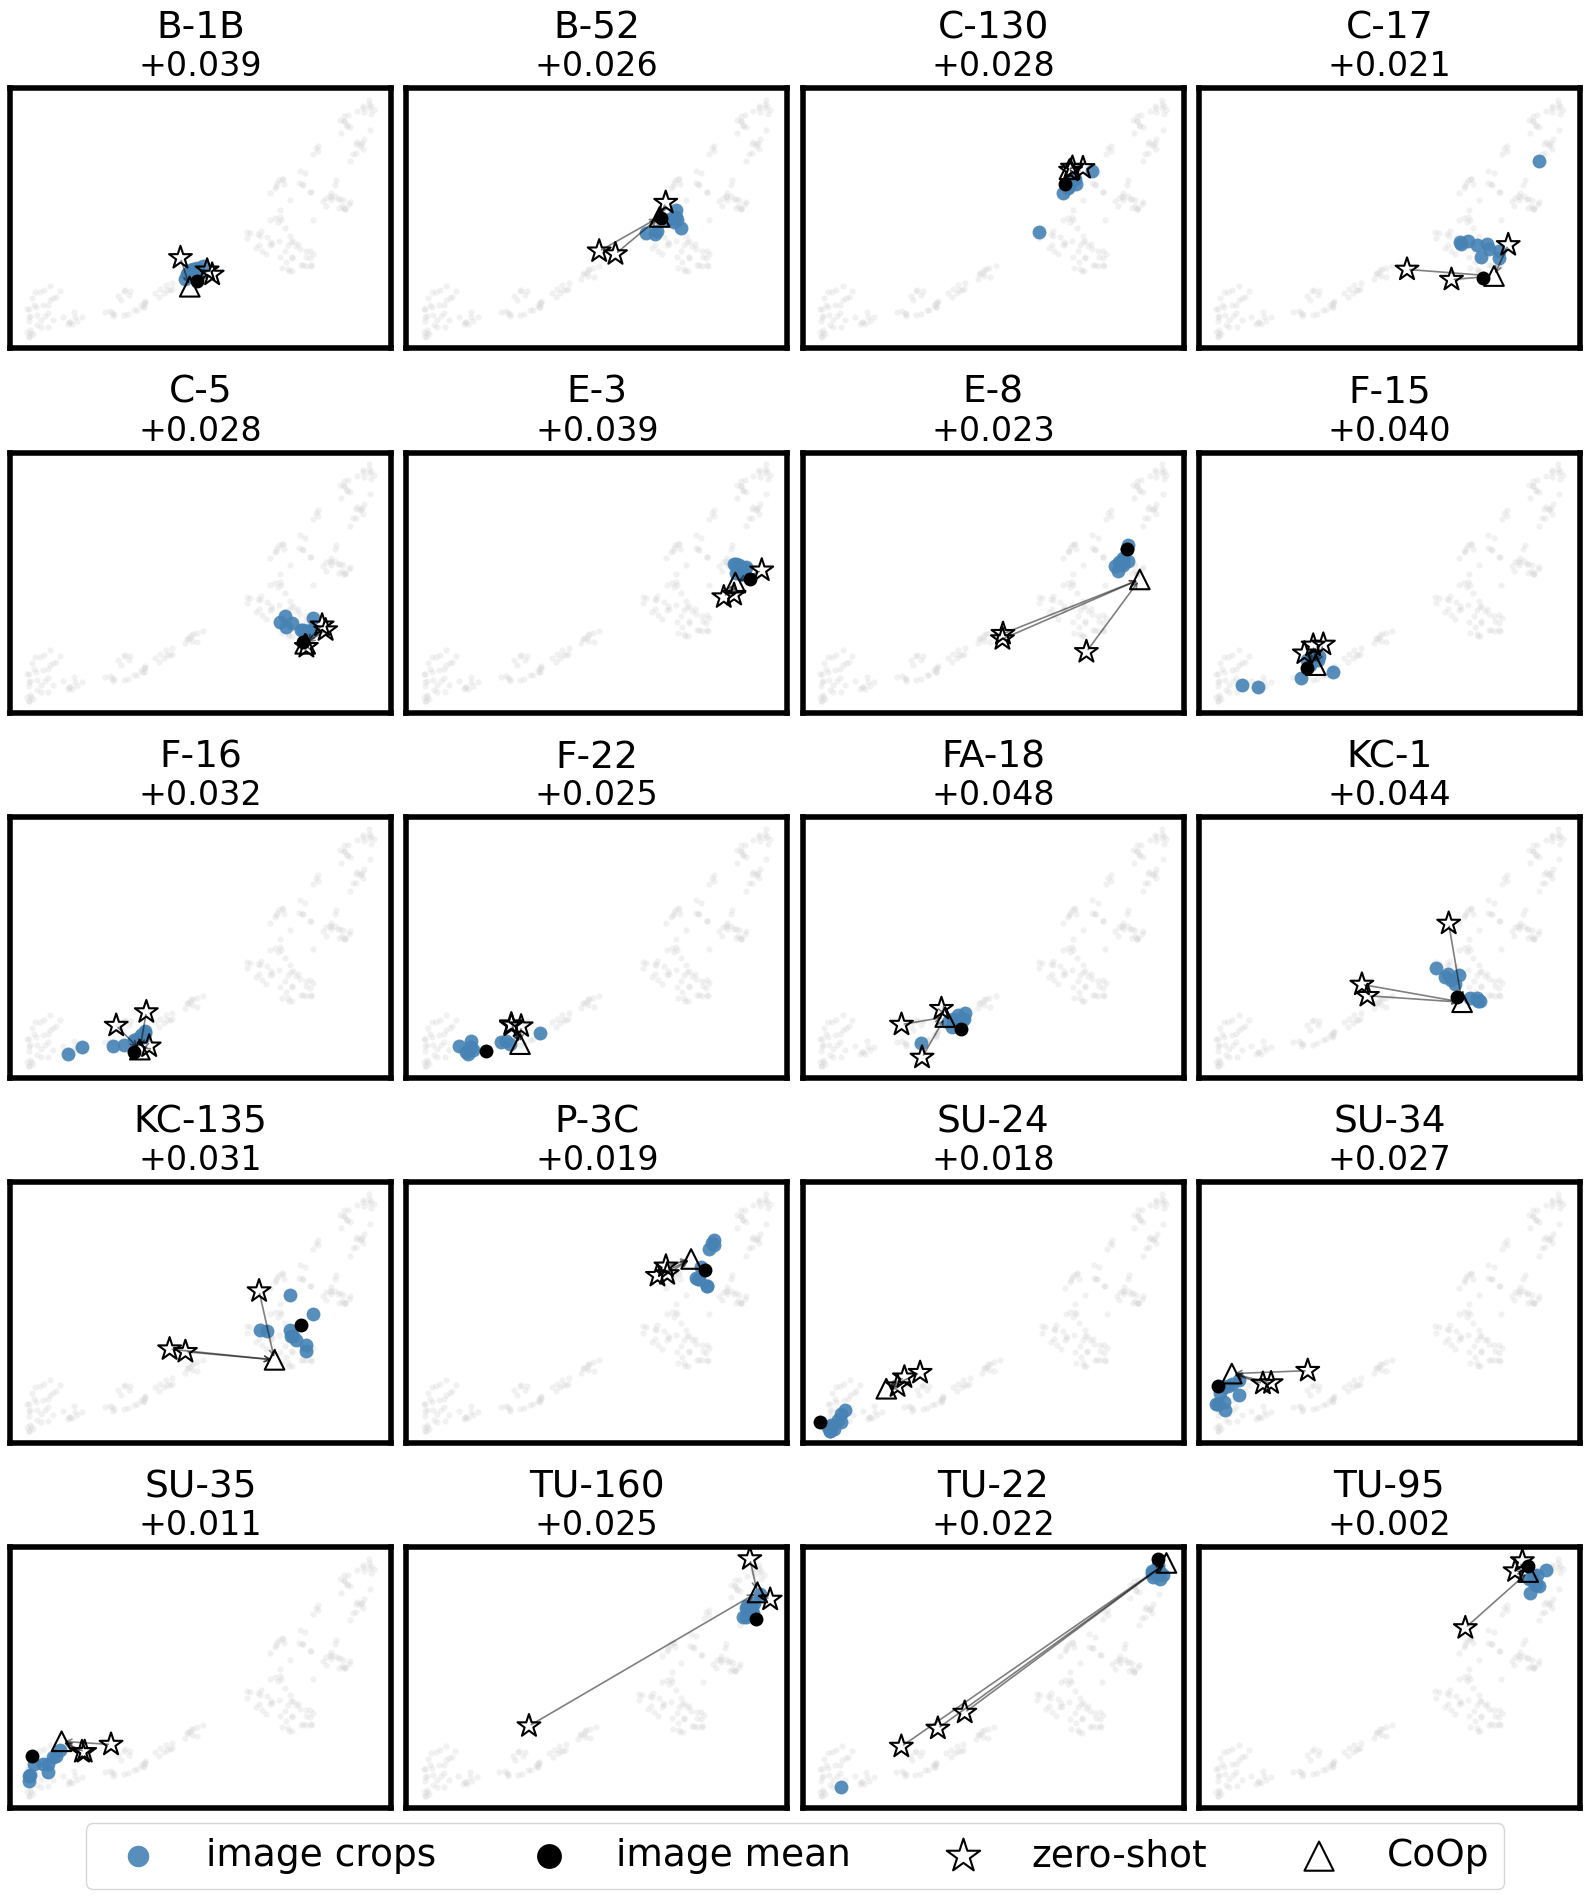

In [34]:
plot_umap_perclass2(
    georsclip_zs_list,
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP Embedding UMAP",
    label_names,
    #display_classes=['B-52', 'C-17', 'E-8', 'F-22', 'FA-18', 'KC-1', 'P-3C', 'SU-24', 'TU-22'],
    save_name='figures/umap_emb.png'
)

In [60]:
# plot_umap_single_class(
#     georsclip_zs_list[1], 
#     georsclip_coop_list,
#     georsclip_crop_embed_list,
#     "GeoRSCLIP, TU-95 Aircraft",
#     'TU-95',
#     label_names
# )

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


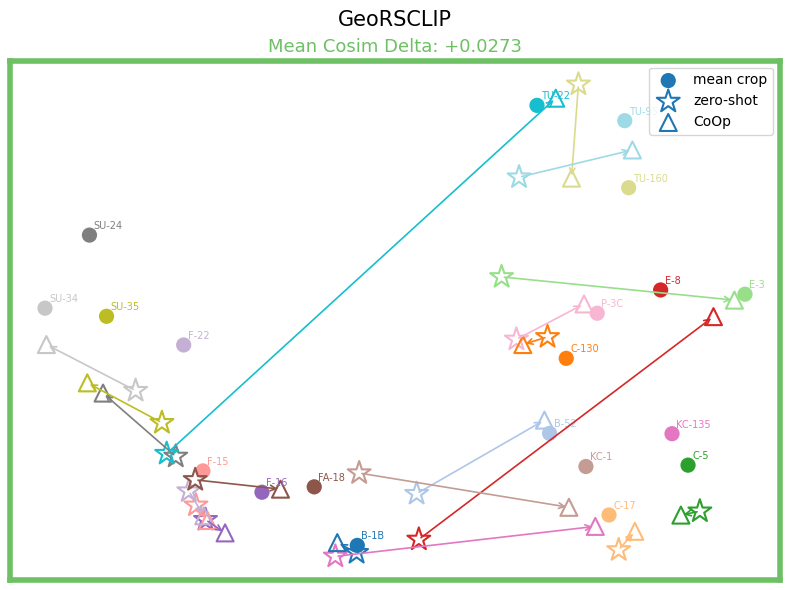

In [112]:
plot_umap_simple(
    georsclip_zs_list[1],
    georsclip_coop_list,
    georsclip_crop_embed_list,
    "GeoRSCLIP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


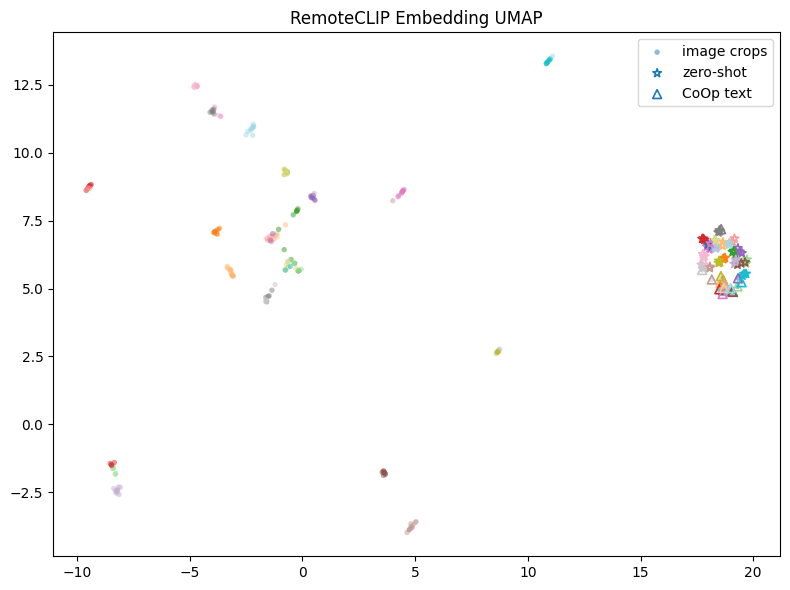

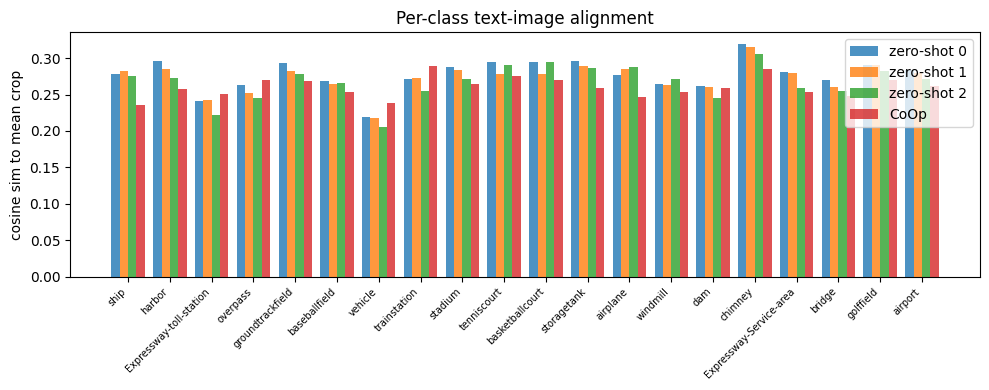

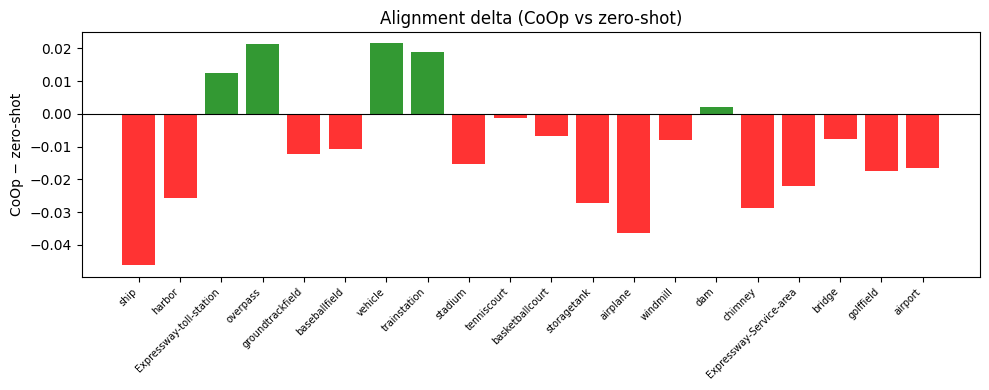

In [99]:
plot_umap(
    remoteclip_zs_list,
    remoteclip_coop_list,
    remoteclip_crop_embed_list,
    "RemoteCLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


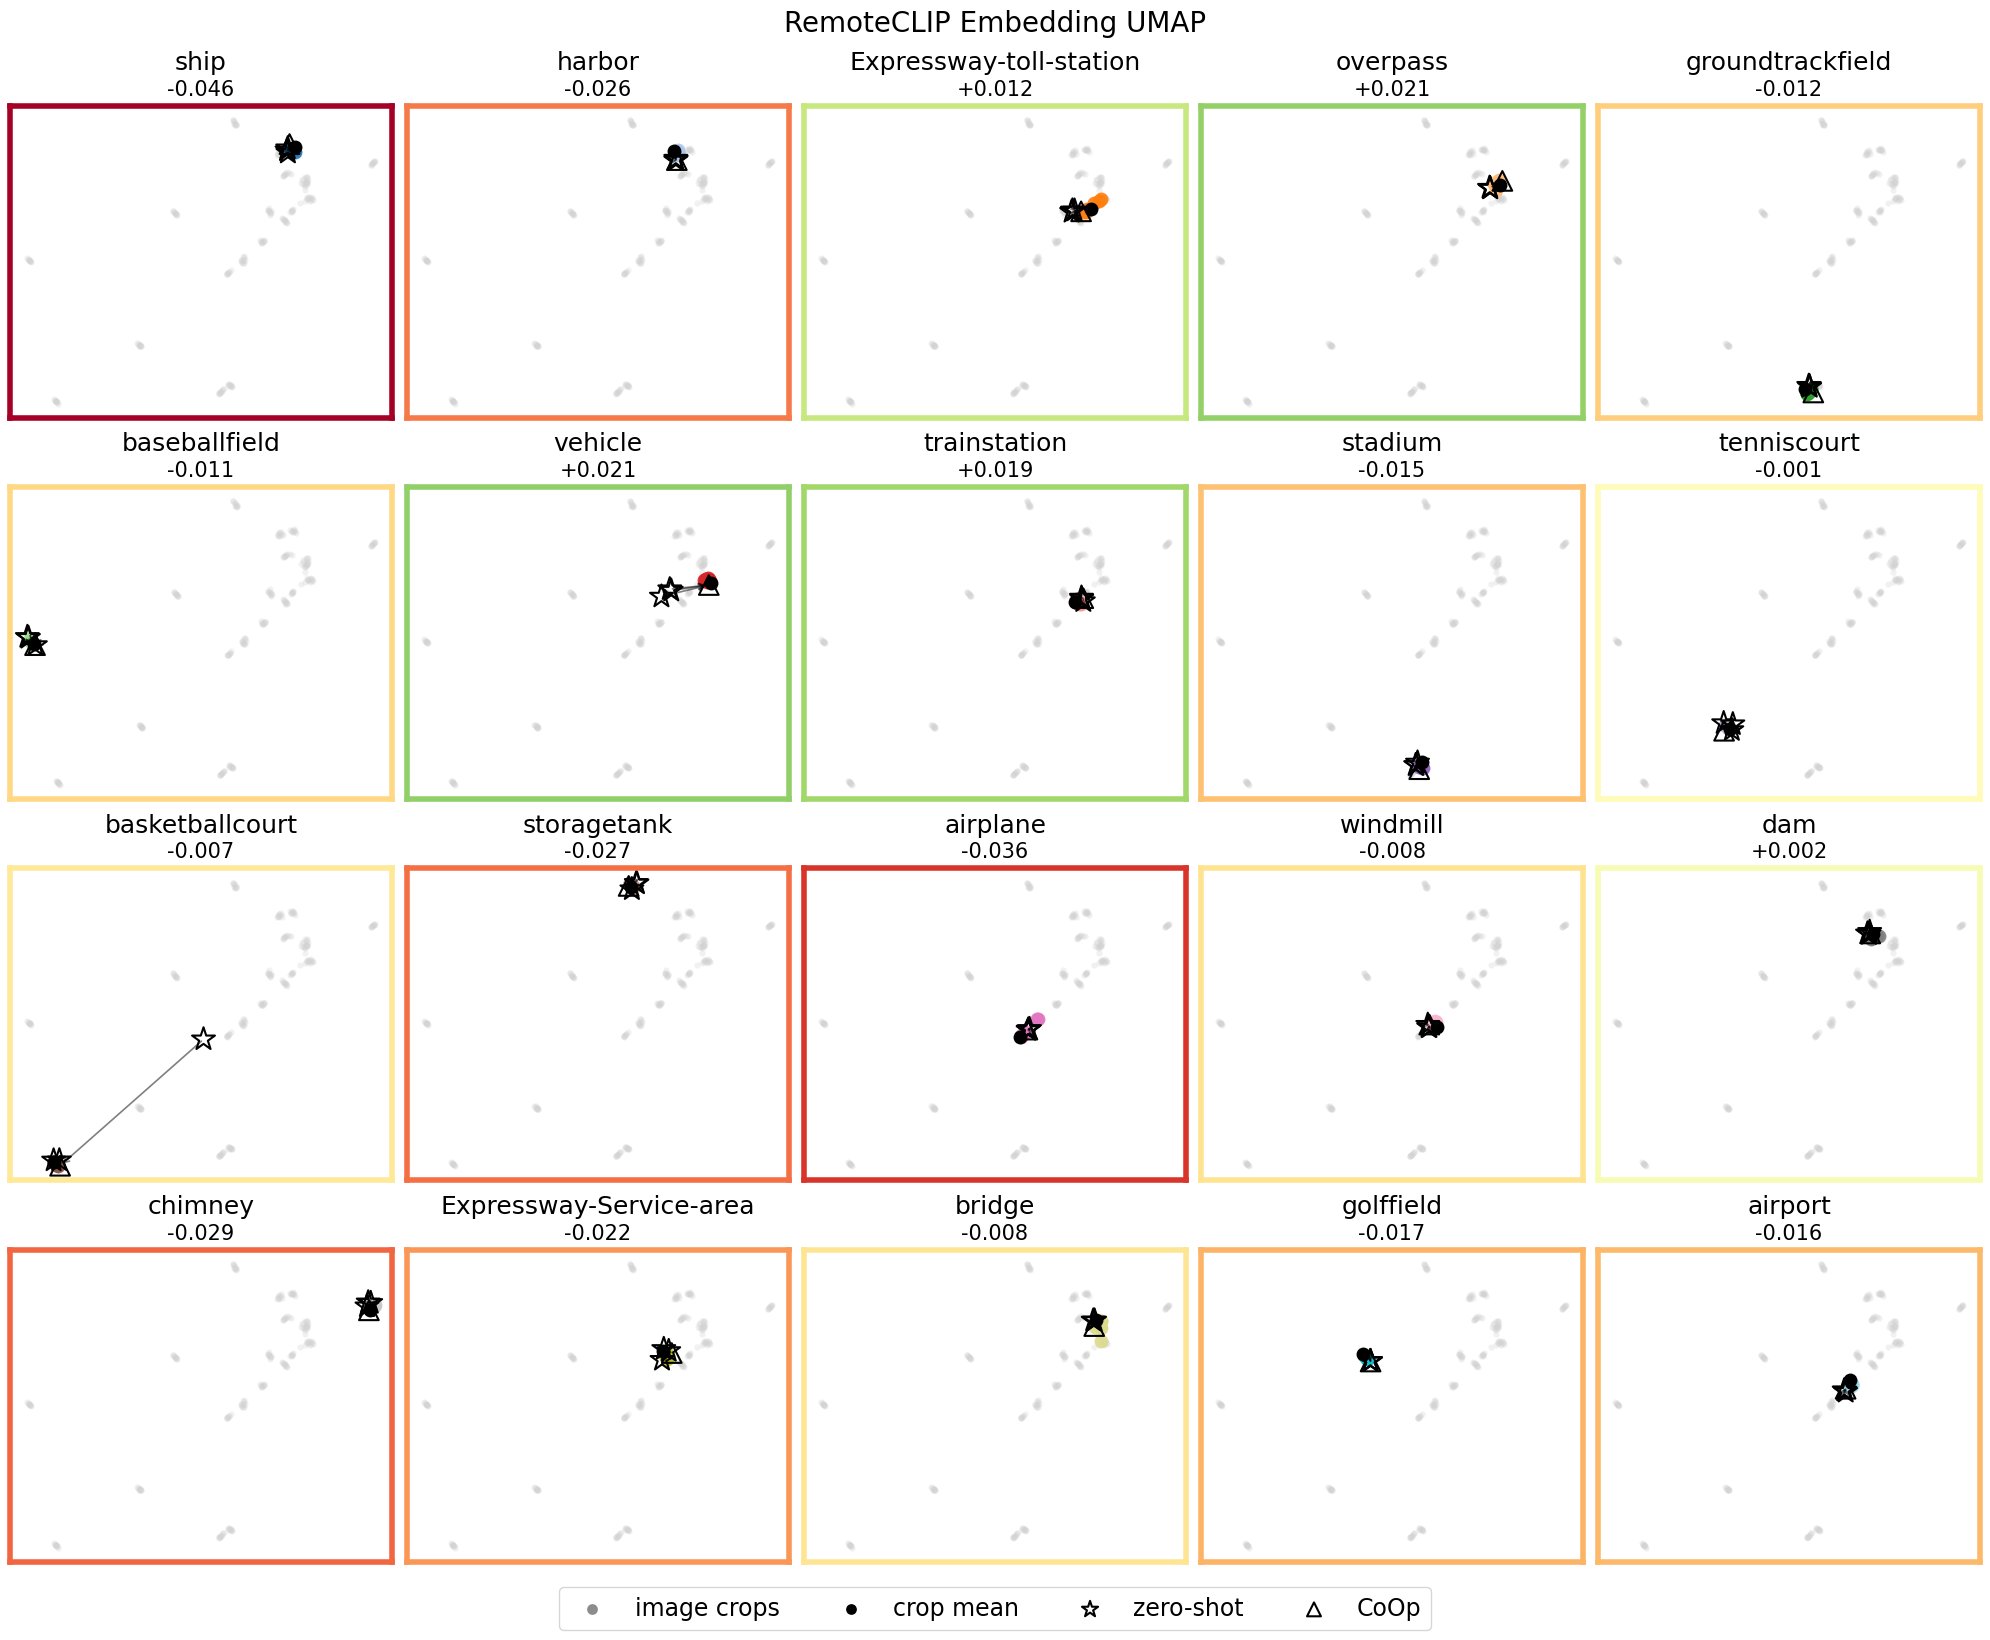

In [68]:
plot_umap_perclass(
    remoteclip_zs_list,
    remoteclip_coop_list,
    remoteclip_crop_embed_list,
    "RemoteCLIP Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


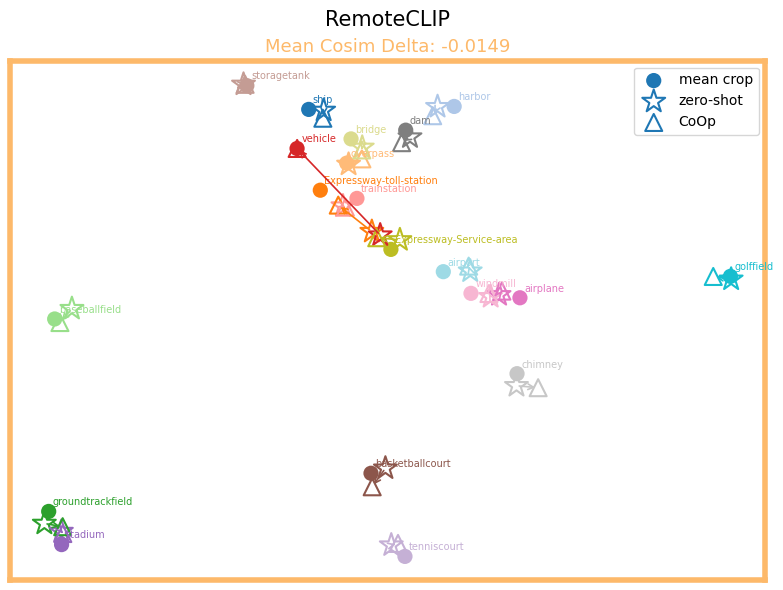

In [101]:
plot_umap_simple(
    remoteclip_zs_list[0],
    remoteclip_coop_list,
    remoteclip_crop_embed_list,
    "RemoteCLIP",
    label_names
)

### Dataset Summary

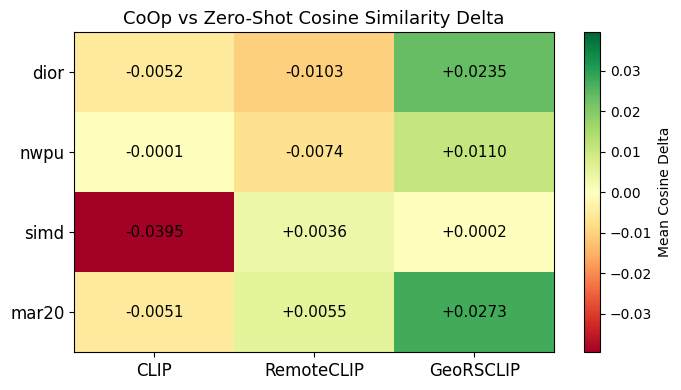

In [20]:
# data = {
#     'dior':  [-0.0717, +0.0118, -0.0234],
#     'nwpu':  [-0.0591, +0.0163, +0.0133],
#     'simd':  [-0.0430, +0.0207, +0.0210],
#     'mar20': [-0.0567, +0.0351, +0.0156],
# }

data = {
    'dior':  [-0.0052, -0.0103, 0.0235],
    'nwpu':  [-0.0001, -0.0074, 0.0110],
    'simd':  [-0.0395, 0.0036, 0.0002],
    'mar20': [-0.0051, 0.0055, 0.0273],
}
    
models   = ['CLIP', 'RemoteCLIP', 'GeoRSCLIP']
datasets = list(data.keys())

values = np.array(list(data.values()))  # (4, 3)
abs_max    = np.abs(values).max()
delta_norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
delta_cmap = plt.get_cmap('RdYlGn')

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(values, cmap='RdYlGn', norm=delta_norm, aspect='auto')

ax.set_xticks(range(len(models)));   ax.set_xticklabels(models, fontsize=12)
ax.set_yticks(range(len(datasets))); ax.set_yticklabels(datasets, fontsize=12)

for i in range(len(datasets)):
    for j in range(len(models)):
        ax.text(j, i, f"{values[i, j]:+.4f}", ha='center', va='center',
                fontsize=11, color='black')

plt.colorbar(im, ax=ax, label='Mean Cosine Delta')
ax.set_title('CoOp vs Zero-Shot Cosine Similarity Delta', fontsize=13)
plt.tight_layout()
plt.savefig('figures/cosim_compare.png', dpi=300, bbox_inches="tight")
plt.show()

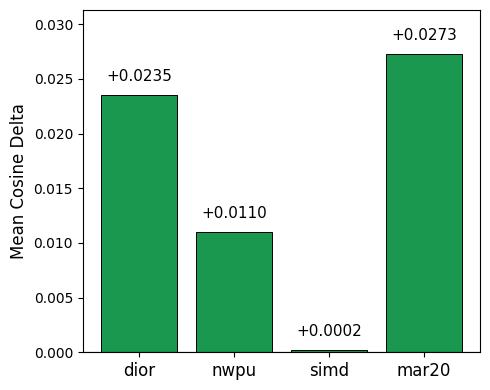

In [28]:
geo_values = [data[d][2] for d in datasets]  # index 2 = GeoRSCLIP

colors = ['#d73027' if v < 0 else '#1a9850' for v in geo_values]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(datasets, geo_values, color=colors, edgecolor='black', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Cosine Delta', fontsize=12)
#ax.set_title('Cosine Delta for GeoRSCLIP', fontsize=13)
ax.set_xticks(range(len(datasets)))
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylim(0, max(geo_values) + 0.004)

for bar, val in zip(bars, geo_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.001 if val >= 0 else -0.001),
            f'{val:+.4f}',
            ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=11)

plt.tight_layout()
plt.savefig('figures/georsclip_bar.png', dpi=300, bbox_inches='tight')
plt.show()

### Visual features

In [129]:
from scipy.spatial import ConvexHull

def plot_umap_crops(crop_embed, title, class_names=None):
    crop_embed = crop_embed.detach().cpu().float()
    C, S, D = crop_embed.shape

    Z = umap.UMAP(n_components=2, metric="cosine", random_state=0).fit_transform(crop_embed.reshape(-1, D).numpy())

    cmap, norm = plt.get_cmap("tab20"), plt.Normalize(0, C-1)
    cls_colors = cmap(norm(np.arange(C)))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(Z[:, 0], Z[:, 1], c=np.repeat(np.arange(C), S), cmap="tab20", vmin=0, vmax=C-1, marker=".", s=60, alpha=0.5, linewidths=0)
  
    for i in range(C):
        pts = Z[i*S:(i+1)*S]
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ax.plot(pts[simplex, 0], pts[simplex, 1], color=cls_colors[i], linewidth=0.8, alpha=0.4)
        except: pass

    if class_names:
        handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=cls_colors[i], label=class_names[i], markersize=6) for i in range(C)]
        ax.legend(handles=handles, fontsize=7, ncol=2)
    ax.set_title(title); plt.tight_layout(); plt.show()

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


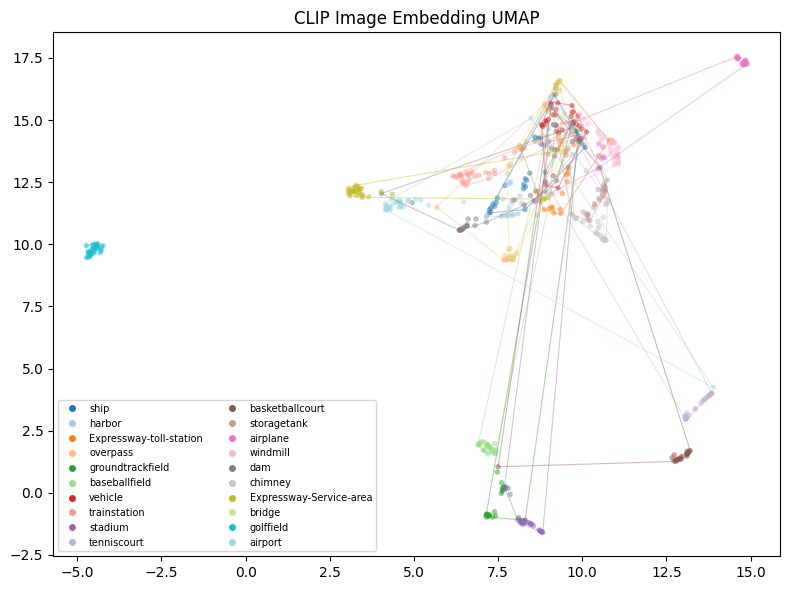

In [130]:
plot_umap_crops(
    clip_crop_embed_list,
    "CLIP Image Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


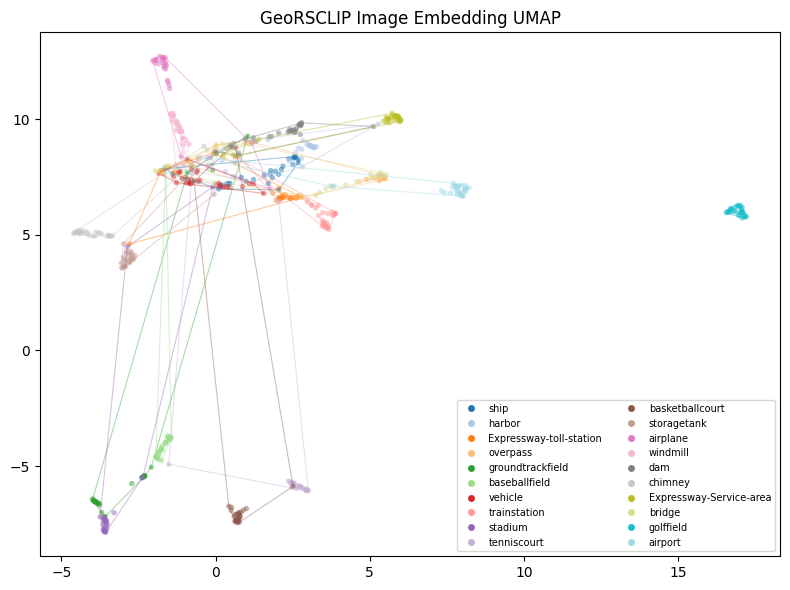

In [131]:
plot_umap_crops(
    georsclip_crop_embed_list,
    "GeoRSCLIP Image Embedding UMAP",
    label_names
)

/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


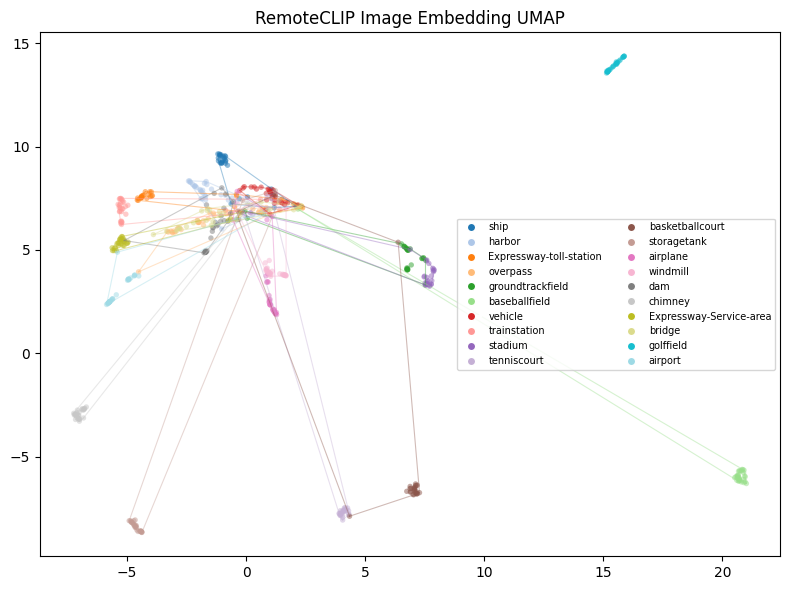

In [132]:
plot_umap_crops(
    remoteclip_crop_embed_list,
    "RemoteCLIP Image Embedding UMAP",
    label_names
)

In [133]:
from sklearn.metrics import silhouette_score
C, S, D = clip_crop_embed_list.shape
score = silhouette_score(clip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

C, S, D = georsclip_crop_embed_list.shape
score = silhouette_score(georsclip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

C, S, D = remoteclip_crop_embed_list.shape
score = silhouette_score(remoteclip_crop_embed_list.detach().cpu().float().reshape(-1, D).numpy(), np.repeat(np.arange(C), S), metric="cosine")
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.089
Silhouette score: 0.163
Silhouette score: 0.214
